# **1-Load Needed Libraries and Preproccessing**

---



---



In [1]:

import kagglehub

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)
import shap

path = kagglehub.dataset_download("brandao/diabetes")
print("Path to dataset files:", path)

import os
file_path = os.path.join(path, [f for f in os.listdir(path) if f.endswith('.csv')][0])
df = pd.read_csv(file_path)

print("Original dataset shape:", df.shape)
df

Using Colab cache for faster access to the 'diabetes' dataset.
Path to dataset files: /kaggle/input/diabetes
Original dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [2]:
df["weight"].value_counts()

,count
weight,
?,98569
[75-100),1336
[50-75),897
[100-125),625
[125-150),145
[25-50),97
[0-25),48
[150-175),35
[175-200),11


In [3]:
df["payer_code"].value_counts()

,count
payer_code,
?,40256
MC,32439
HM,6274
SP,5007
BC,4655
MD,3532
CP,2533
UN,2448
CM,1937


In [4]:

df.isnull().sum()


,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [5]:
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [6]:
df.shape

(101766, 50)

In [7]:
df = df[df['race'] != '?']

In [8]:
df = df[df['gender'] != 'Unknown/Invalid']

Key discharge_disposition_id Mappings
The dataset uses 29 distinct values, with the most important mappings including:

1: Discharged to Home

3: Discharged/transferred to Skilled Nursing Facility (SNF)

6: Discharged/transferred to home with home health service

11, 19, 20, 21: Expired (Patient deceased)

18: Null/Not Mapped

In [9]:
def map_discharge(x):
    if x == 1:
        return "Home"
    elif x in [3, 6]:
        return "Care"
    elif x == 2:
        return "Transfer"
    elif x in [11, 19, 20, 21]:
        return "Death"
    elif x in [13, 14]:
        return "Hospice"
    elif x == 18:
        return "Unknown"
    else:
        return "Other"

df['discharge_group'] = df['discharge_disposition_id'].apply(map_discharge)

In [10]:
df = df[df['discharge_group'] != 'Unknown']

Column: metformin-rosiglitazone -------------------------------------------------- metformin-rosiglitazone

 No 95819

zero variance feature

In [11]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'discharge_group'],
      dtype='object')

In [12]:
df_c = df.drop(columns=[
    'discharge_disposition_id',
    'metformin-pioglitazone',
    'glyburide-metformin',
    'glimepiride-pioglitazone',
    'encounter_id',
    'patient_nbr',
    'weight',
    'max_glu_serum',
    'A1Cresult',
    'payer_code',
    'medical_specialty',
    'glipizide-metformin',
    'metformin-rosiglitazone',
    'examide',
    'citoglipton',
    'acetohexamide',
    'troglitazone',
    'tolbutamide',
    'tolazamide',
    'chlorpropamide', 'miglitol', 'acarbose',
    'nateglinide', 'repaglinide'
])

In [13]:
df_c.shape

(95819, 27)

In [14]:
def map_icd9(code):
    try:
        c = str(code).strip()
        if c.startswith('V'): return 'Supplementary'
        if c.startswith('E'): return 'External_Causes'
        n = float(c)
        if n < 140:  return 'Infectious'
        if n < 240:  return 'Neoplasms'
        if n < 280:  return 'Endocrine_Diabetes'
        if n < 290:  return 'Blood'
        if n < 320:  return 'Mental'
        if n < 360:  return 'Nervous_System'
        if n < 390:  return 'Sensory'
        if n < 460:  return 'Circulatory'       # 428=heart failure, 410=MI
        if n < 520:  return 'Respiratory'       # 486=pneumonia
        if n < 580:  return 'Digestive'
        if n < 630:  return 'Genitourinary'
        if n < 680:  return 'Pregnancy'
        if n < 710:  return 'Skin'
        if n < 740:  return 'Musculoskeletal'
        if n < 760:  return 'Congenital'
        if n < 780:  return 'Perinatal'
        if n < 800:  return 'Symptoms'
        return 'Injury'
    except:
        return 'Other'

df_c['diag_1'] = df_c['diag_1'].apply(map_icd9)
df_c['diag_2'] = df_c['diag_2'].apply(map_icd9)
df_c['diag_3'] = df_c['diag_3'].apply(map_icd9)

In [15]:
df_c.isnull().sum().sum()

np.int64(0)

In [16]:
df_c.duplicated().sum()

np.int64(1)

In [17]:
df_c.drop_duplicates( inplace = True)

In [18]:
age_map = {
    '[0-10)':0, '[10-20)':1, '[20-30)':2, '[30-40)':3,
    '[40-50)':4, '[50-60)':5, '[60-70)':6, '[70-80)':7,
    '[80-90)':8, '[90-100)':9
}
df_c['age'] = df_c['age'].map(age_map)

Is the patient:

0 → Will not return
1 → Will return after a long time
2 → Will return soon (dangerous)

In [19]:
readmit_map = {'NO': 0, '>30': 1, '<30': 2}
df_c['readmitted'] = df_c['readmitted'].map(readmit_map)

In [20]:
df_c.columns

Index(['race', 'gender', 'age', 'admission_type_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
       'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted',
       'discharge_group'],
      dtype='object')

In [21]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95818 entries, 0 to 101765
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   race                 95818 non-null  object
 1   gender               95818 non-null  object
 2   age                  95818 non-null  int64 
 3   admission_type_id    95818 non-null  int64 
 4   admission_source_id  95818 non-null  int64 
 5   time_in_hospital     95818 non-null  int64 
 6   num_lab_procedures   95818 non-null  int64 
 7   num_procedures       95818 non-null  int64 
 8   num_medications      95818 non-null  int64 
 9   number_outpatient    95818 non-null  int64 
 10  number_emergency     95818 non-null  int64 
 11  number_inpatient     95818 non-null  int64 
 12  diag_1               95818 non-null  object
 13  diag_2               95818 non-null  object
 14  diag_3               95818 non-null  object
 15  number_diagnoses     95818 non-null  int64 
 16  metformi

In [22]:
df_num = df_c.select_dtypes(include=np.number)


#**Step 2: EDA**
----------------------------------------------------------------------------------------------
------------------------------------------------------------------------

In [23]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

/tmp/ipykernel_4707/3926361904.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_c, x='readmitted', palette='spring')
/tmp/ipykernel_4707/3926361904.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Readmit', '>30 Days', '<30 Days'])


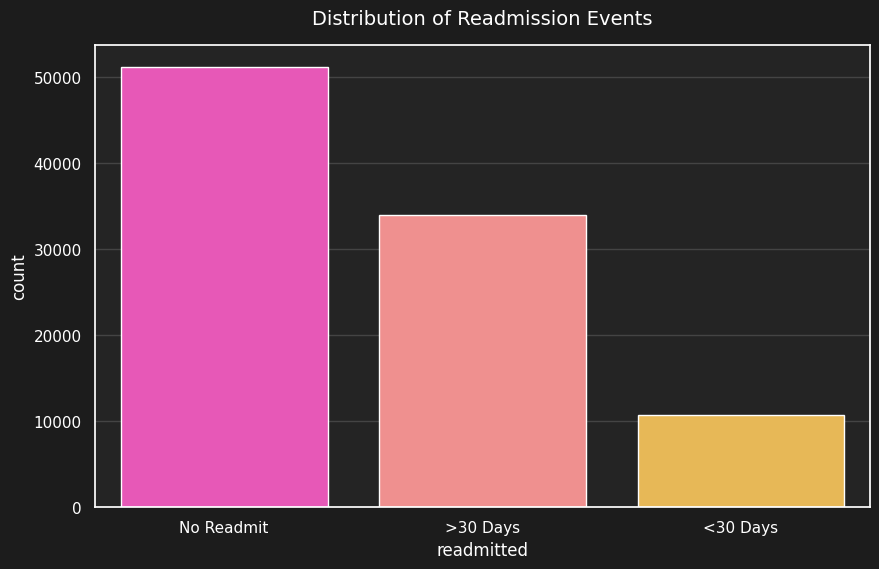

In [24]:

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(10, 6))

ax = sns.countplot(data=df_c, x='readmitted', palette='spring')

plt.title('Distribution of Readmission Events', color='white', fontsize=14, pad=15)
ax.set_xticklabels(['No Readmit', '>30 Days', '<30 Days'])

plt.show()

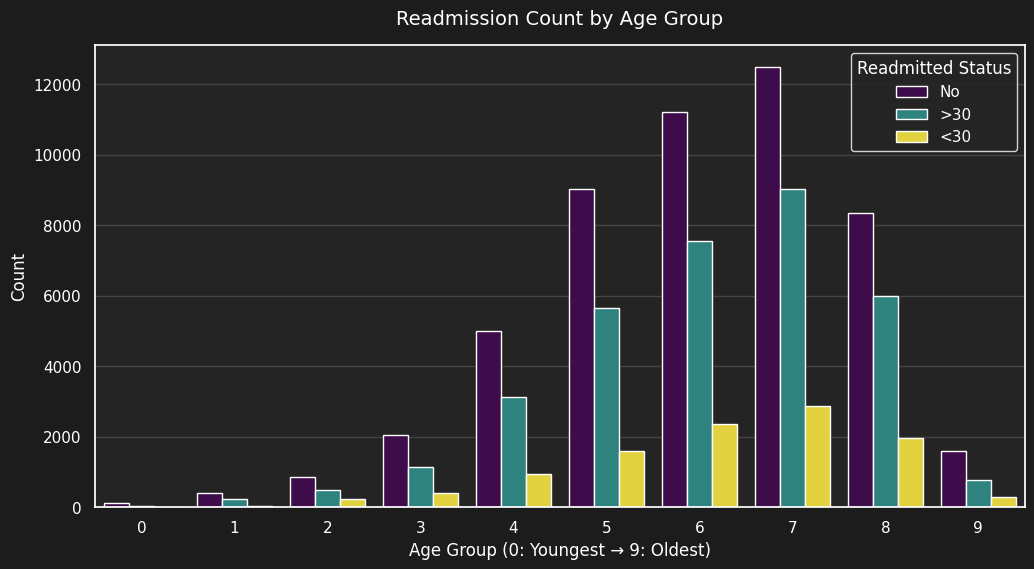

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(12, 6))

ax = sns.countplot(data=df_c, x='age', hue='readmitted', palette='viridis')

plt.title('Readmission Count by Age Group', color='white', fontsize=14, pad=15)
plt.xlabel('Age Group (0: Youngest → 9: Oldest)', color='white')
plt.ylabel('Count', color='white')

legend = plt.legend(title='Readmitted Status', labels=['No', '>30', '<30'],
                    facecolor='#242424', edgecolor='white')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')
plt.show()

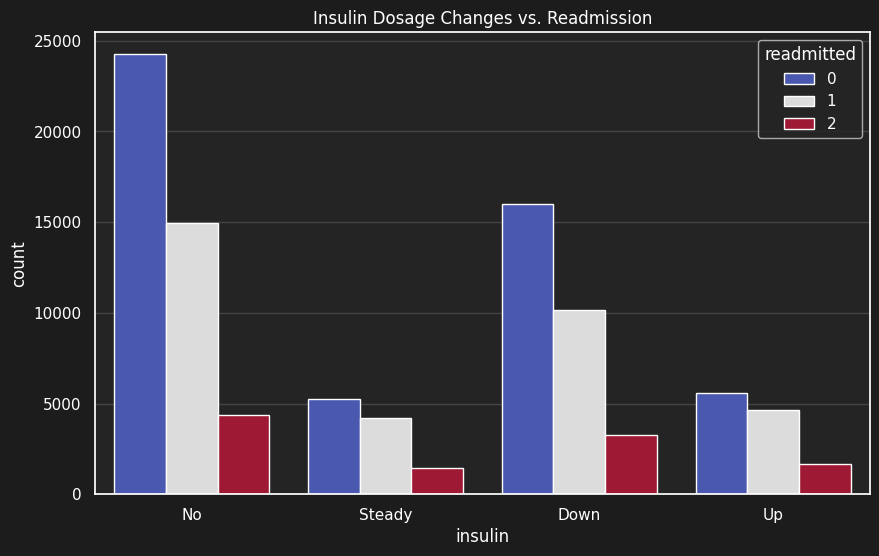

In [26]:

plt.figure(figsize=(10, 6))
sns.countplot(data=df_c, x='insulin', hue='readmitted', palette='coolwarm')
plt.title('Insulin Dosage Changes vs. Readmission')
plt.xticks([0, 1, 2, 3], ['No', 'Steady', 'Down', 'Up'])
plt.show()

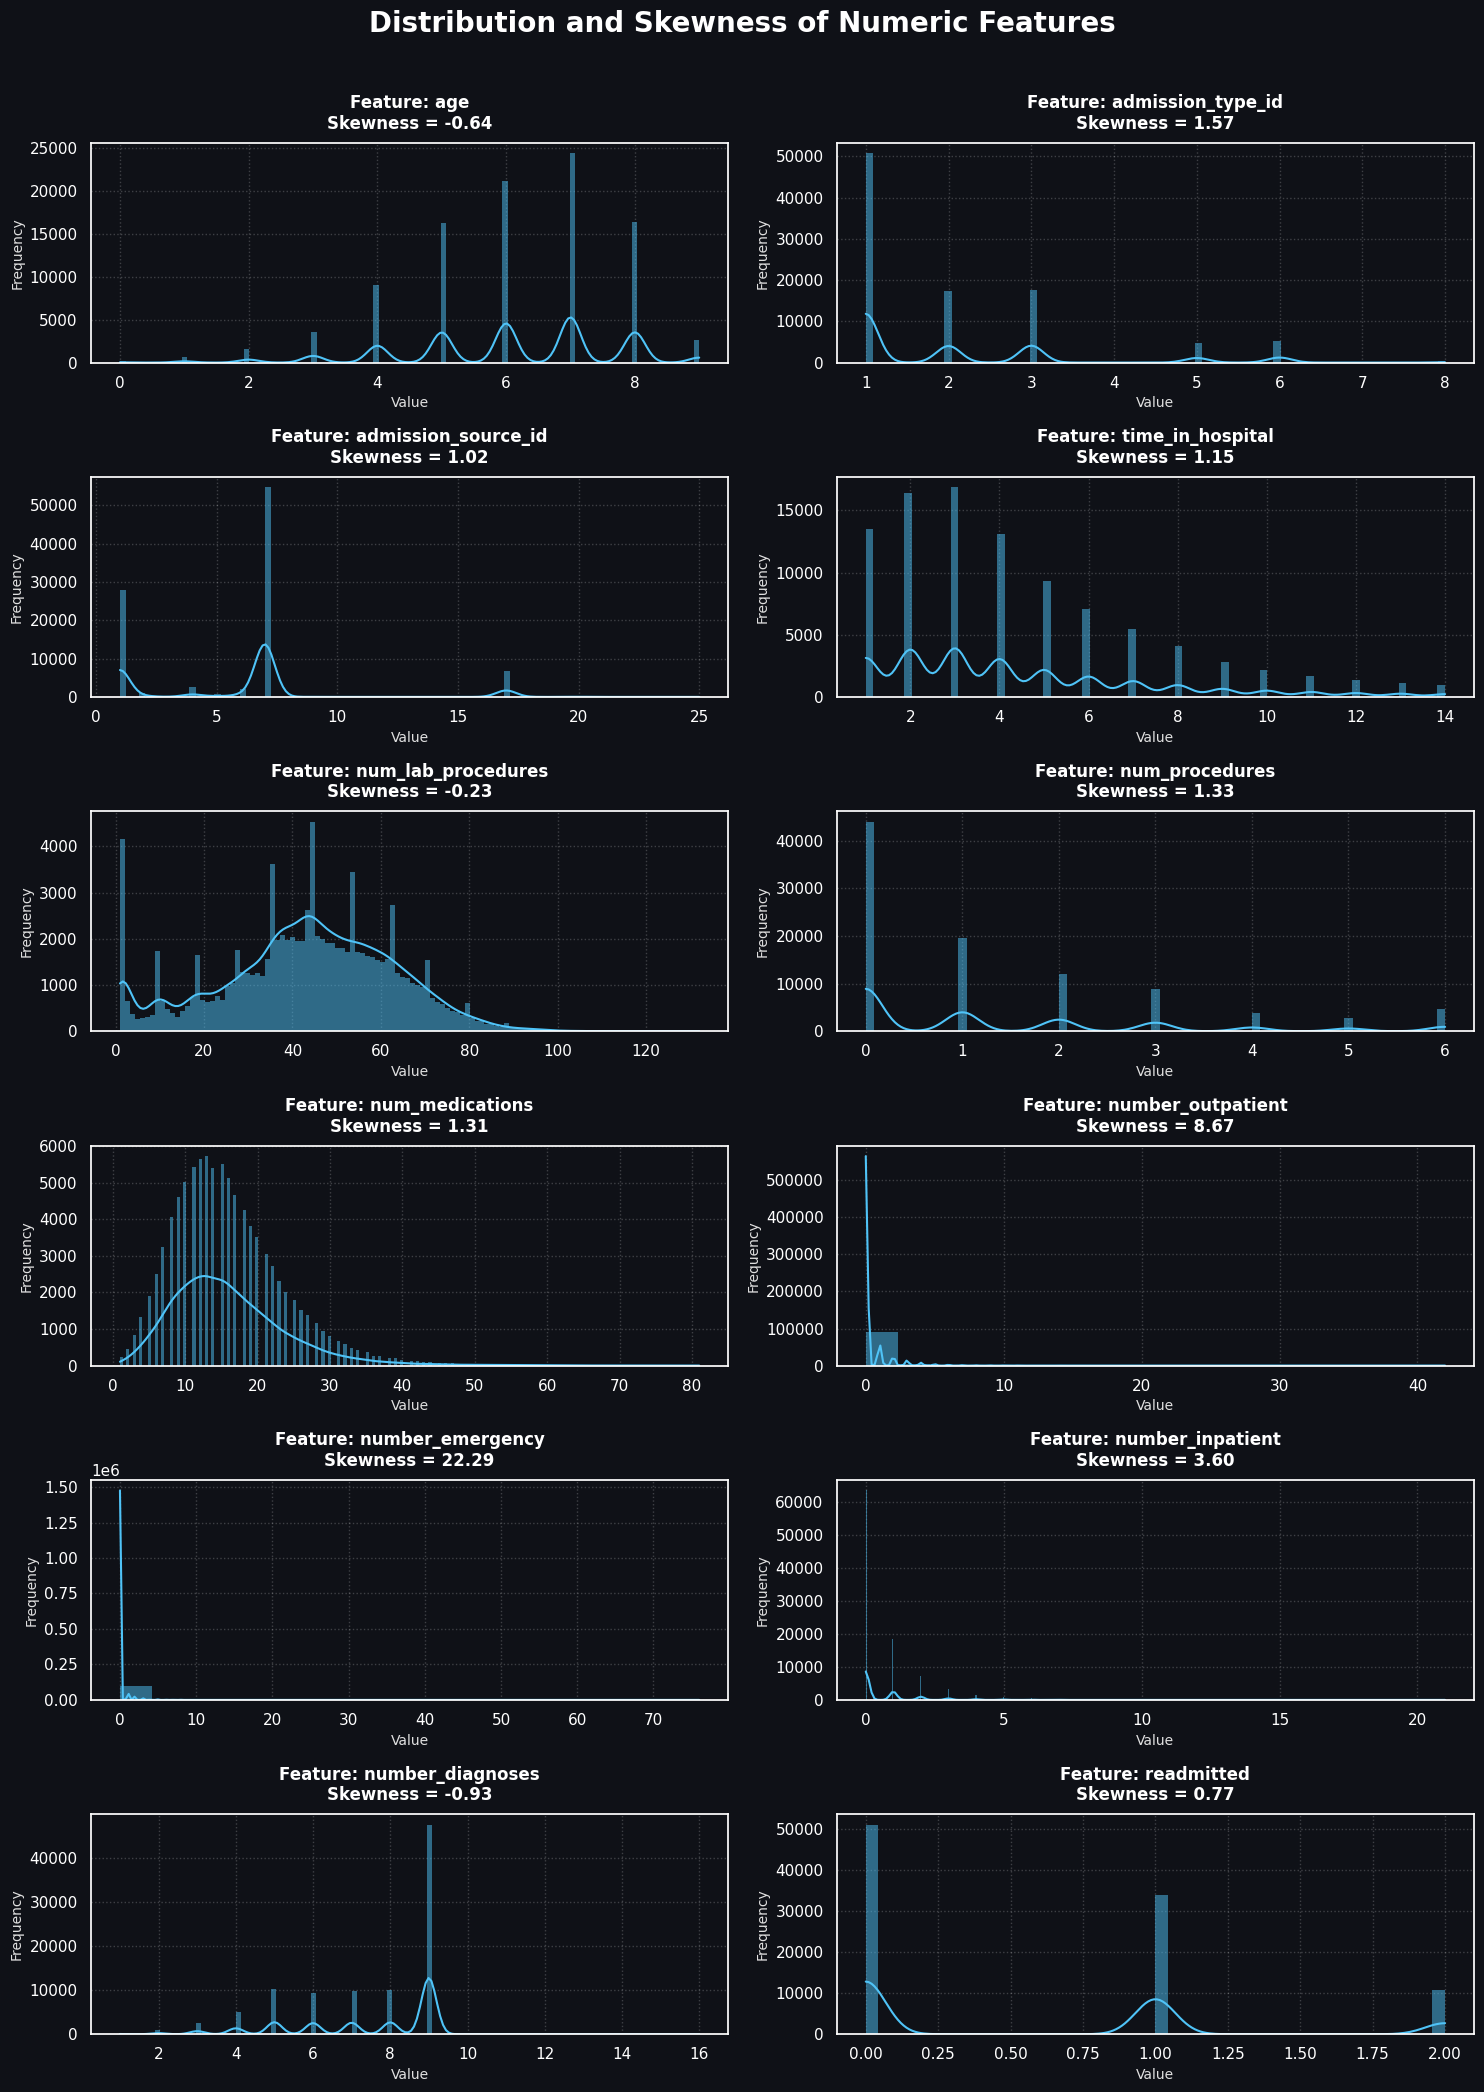

In [27]:

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 22))
fig.set_facecolor('#0f1117')

axes_flat = axes.flatten()

for i, col in enumerate(df_num):
    if i >= len(axes_flat):
        break
    ax = axes_flat[i]
    ax.set_facecolor('#0f1117')

    skew_val = df_c[col].skew()

    sns.histplot(df_c[col], kde=True, color='#4FC3F7', edgecolor='none', ax=ax)

    ax.set_title(f"Feature: {col}\nSkewness = {skew_val:.2f}",
                 fontsize=12, color='white', fontweight='bold', pad=10)
    ax.set_xlabel("Value", fontsize=10, color='#e0e0e0')
    ax.set_ylabel("Frequency", fontsize=10, color='#e0e0e0')

    ax.grid(True, linestyle=':', alpha=0.2, color='white')

    ax.tick_params(colors='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Distribution and Skewness of Numeric Features", color='white', fontsize=20, fontweight='bold')

plt.show()

In [29]:

cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient', 'num_medications', 'time_in_hospital']

for col in cols_to_fix:
    df_c[col] = np.log1p(df_c[col])

print("Skewness after Log Transformation:")
print(df_c[cols_to_fix].skew())

Skewness after Log Transformation:
number_emergency     2.828135
number_outpatient    2.152076
number_inpatient     1.036768
num_medications     -1.179569
time_in_hospital    -0.276139
dtype: float64


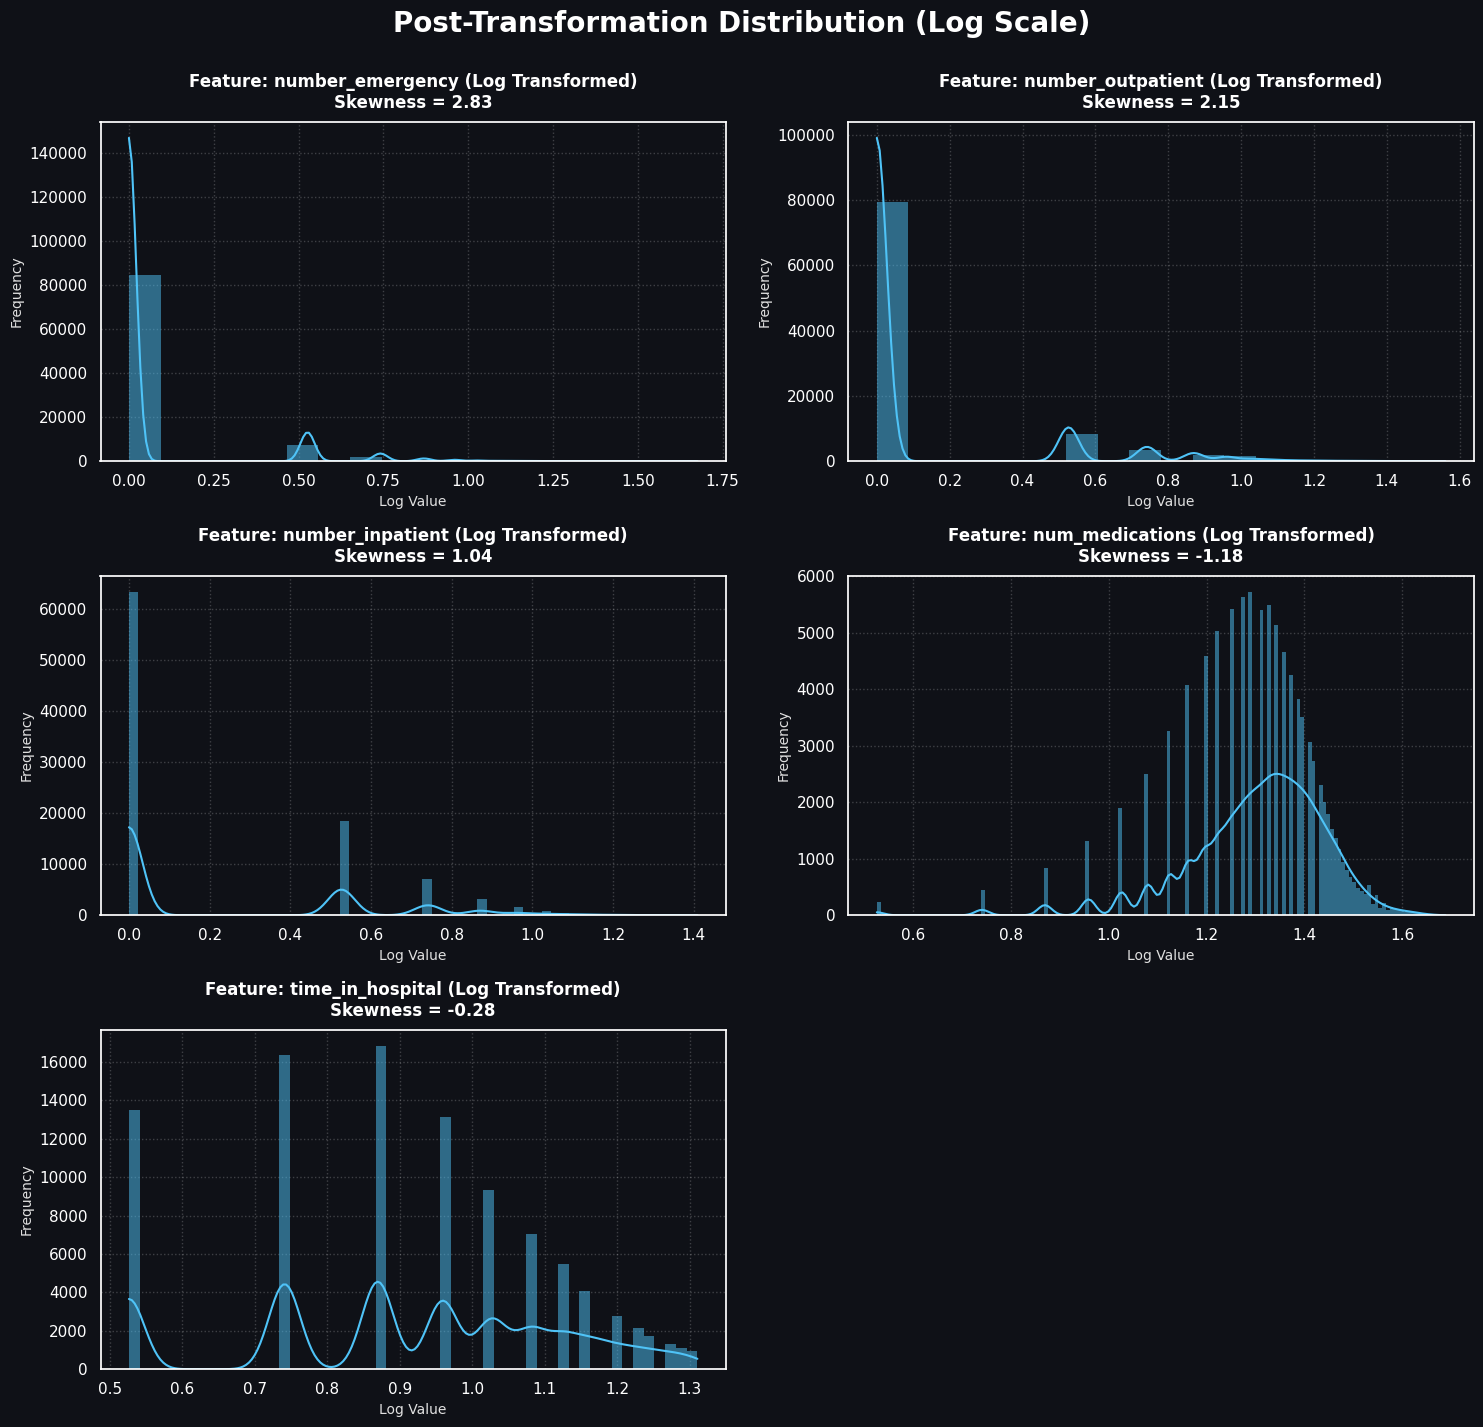

In [30]:


cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient', 'num_medications', 'time_in_hospital']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
fig.set_facecolor('#0f1117')

axes_flat = axes.flatten()

for i, col in enumerate(cols_to_fix):
    ax = axes_flat[i]
    ax.set_facecolor('#0f1117')

    skew_val = df_c[col].skew()

    sns.histplot(df_c[col], kde=True, color='#4FC3F7', edgecolor='none', ax=ax)

    ax.set_title(f"Feature: {col} (Log Transformed)\nSkewness = {skew_val:.2f}",
                 fontsize=12, color='white', fontweight='bold', pad=10)
    ax.set_xlabel("Log Value", fontsize=10, color='#e0e0e0')
    ax.set_ylabel("Frequency", fontsize=10, color='#e0e0e0')
    ax.grid(True, linestyle=':', alpha=0.2, color='white')
    ax.tick_params(colors='white')

axes_flat[5].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Post-Transformation Distribution (Log Scale)", color='white', fontsize=20, fontweight='bold')

plt.show()

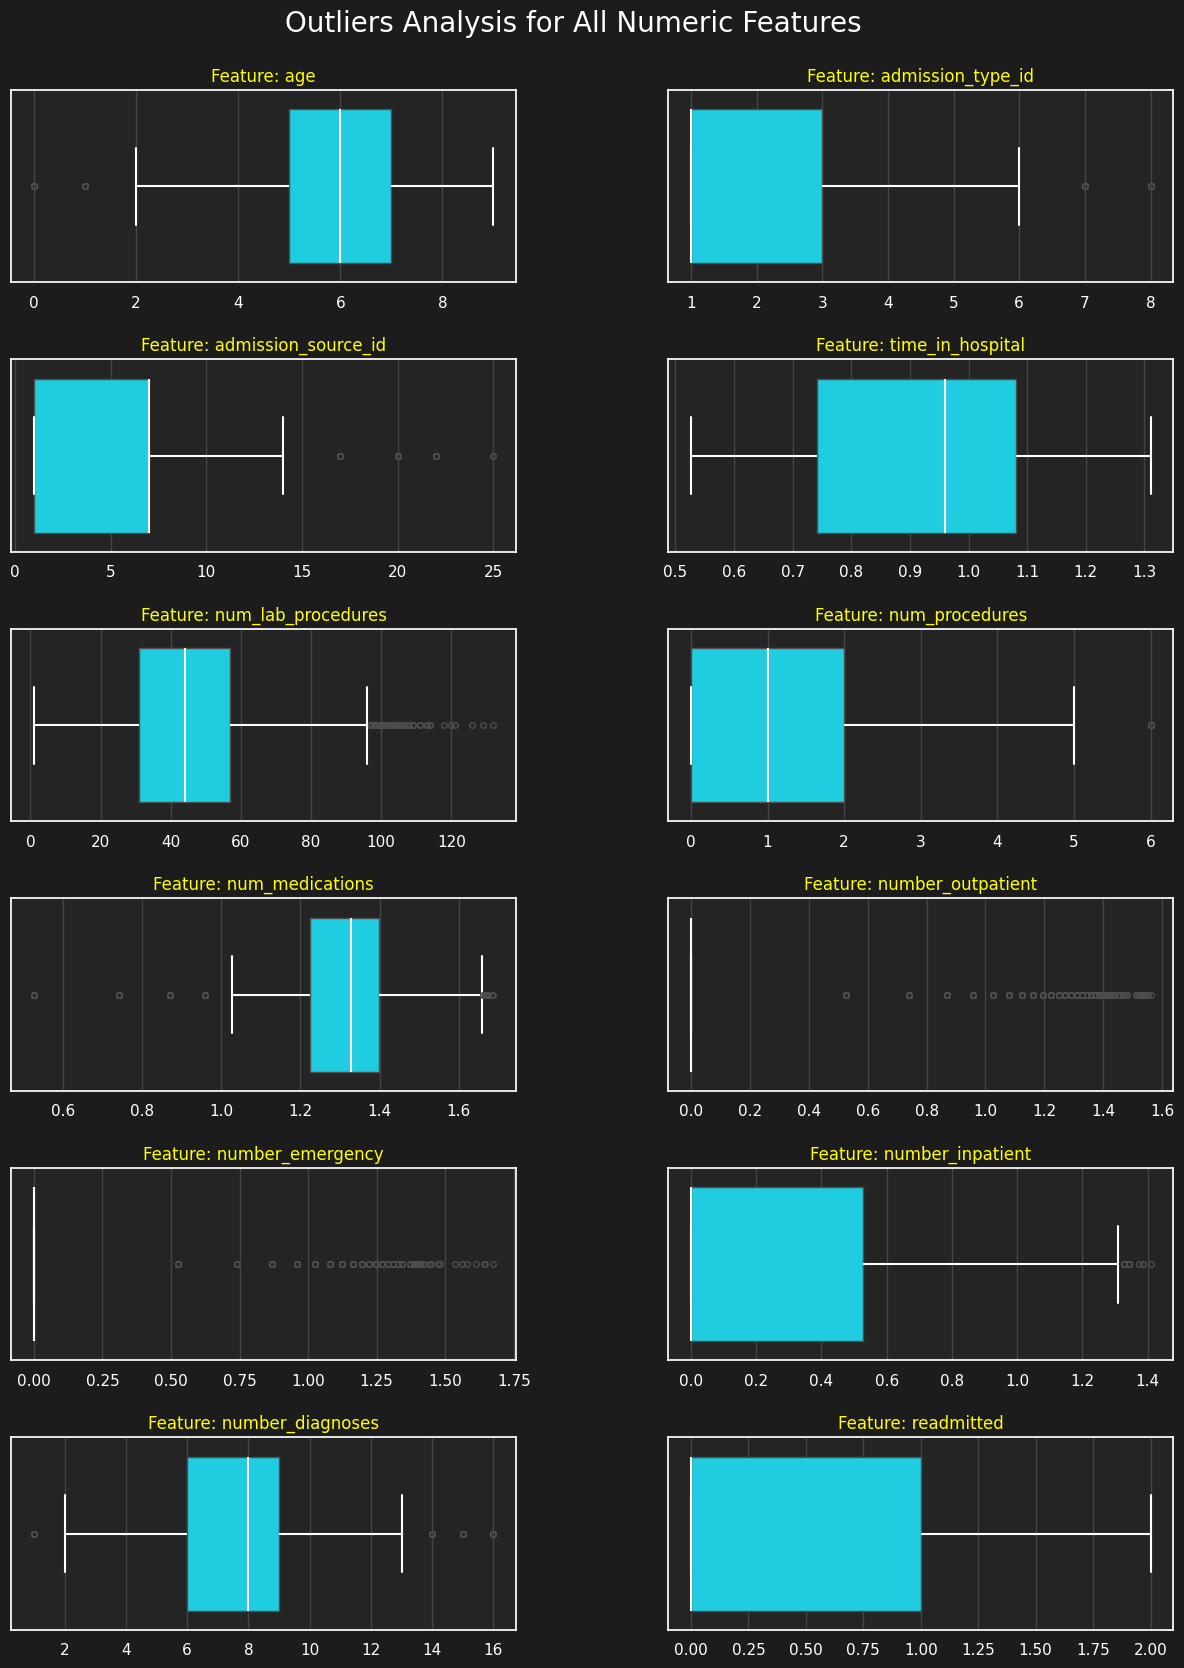

In [31]:

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})



fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('Outliers Analysis for All Numeric Features', color='white', fontsize=20, y=0.92)

axes_flat = axes.flatten()

for i, col in enumerate(df_num):
    ax = axes_flat[i]

    sns.boxplot(x=df_c[col], ax=ax, color='#00e5ff', fliersize=4)

    plt.setp(ax.artists, edgecolor="white", linewidth=1.5)
    plt.setp(ax.lines, color="white", linewidth=1.5)

    ax.set_title(f'Feature: {col}', color='yellow', fontsize=12)
    ax.set_xlabel('')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.show()

In [32]:


print(f"{'Feature':<25} | {'Outliers Count':<15} | {'Percentage':<10}")
print("-" * 55)

total_rows = len(df_c)

for col in df_num:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_c[(df_c[col] < lower_bound) | (df_c[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / total_rows) * 100

    print(f"{col:<25} | {count:<15} | {percentage:.2f}%")

Feature                   | Outliers Count  | Percentage
-------------------------------------------------------
age                       | 838             | 0.87%
admission_type_id         | 337             | 0.35%
admission_source_id       | 6866            | 7.17%
time_in_hospital          | 0               | 0.00%
num_lab_procedures        | 142             | 0.15%
num_procedures            | 4582            | 4.78%
num_medications           | 2848            | 2.97%
number_outpatient         | 16389           | 17.10%
number_emergency          | 11272           | 11.76%
number_inpatient          | 19              | 0.02%
number_diagnoses          | 261             | 0.27%
readmitted                | 0               | 0.00%


In [38]:
safe_to_cap = ['age', 'num_lab_procedures', 'num_medications', 'number_diagnoses', 'time_in_hospital']

for col in safe_to_cap:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_c[col] = df_c[col].clip(lower=lower_bound, upper=upper_bound)


print("Selective Capping completed. Emergency and Outpatient features preserved.")

Selective Capping completed. Emergency and Outpatient features preserved.


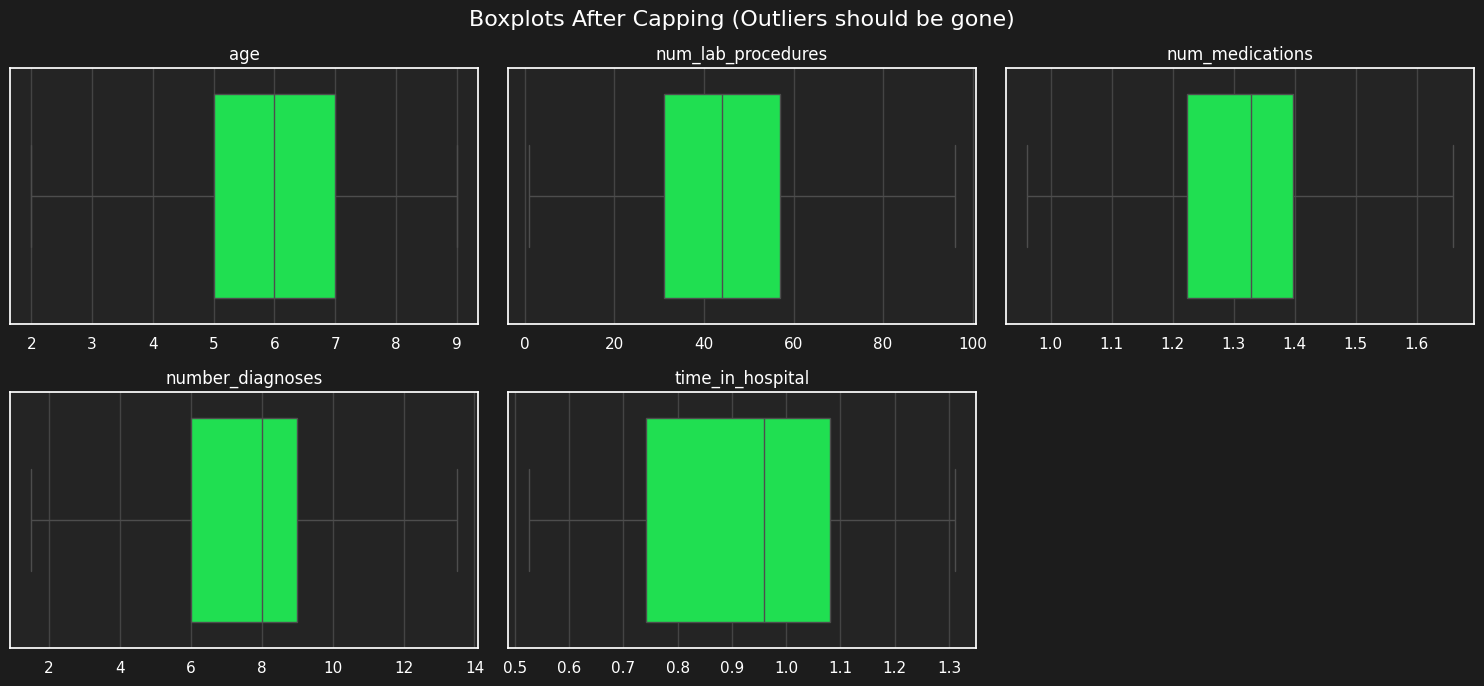

In [40]:
plt.figure(figsize=(15, 10))
plt.suptitle("Boxplots After Capping (Outliers should be gone)", color='white', fontsize=16)

for i, col in enumerate(safe_to_cap):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df_c[col], color='#00ff41')
    plt.title(col, color='white')
    plt.xlabel('')

plt.tight_layout()
plt.show()

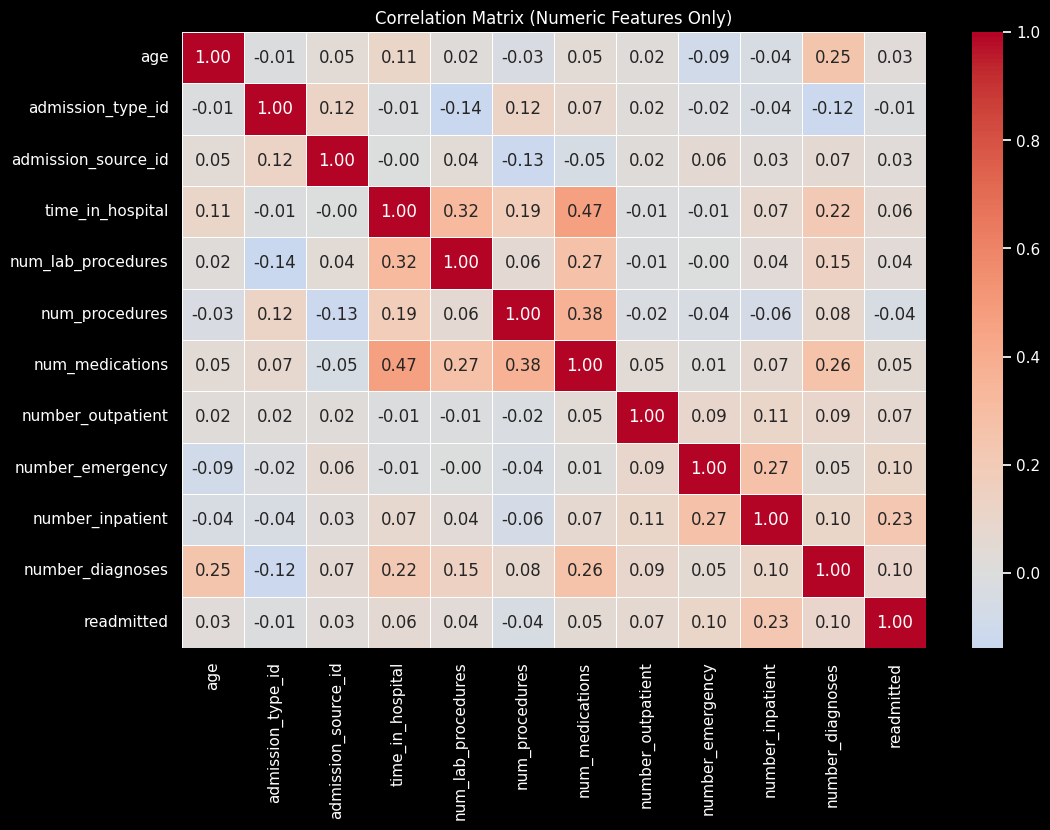

readmitted             1.000000
number_inpatient       0.233497
number_emergency       0.104288
number_diagnoses       0.100961
number_outpatient      0.067485
time_in_hospital       0.057634
num_medications        0.054058
num_lab_procedures     0.036428
age                    0.031047
admission_source_id    0.028534
admission_type_id     -0.008632
num_procedures        -0.036341
Name: readmitted, dtype: float64


In [46]:

corr_matrix = df_num.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

corr_with_target = corr_matrix['readmitted'].sort_values(ascending=False)
print(corr_with_target)


#**Feature Engineering/Selection**
----------------------------------------------------------------------------------------
--------------------------------------------------------------------


In [47]:
df_c = df_c.drop(columns=['admission_type_id', 'num_procedures'])

In [48]:
cat_cols = ['race', 'gender', 'change', 'diabetesMed',
            'discharge_group', 'diag_1', 'diag_2', 'diag_3']

df_c = pd.get_dummies(df_c, columns=cat_cols, drop_first=True)

In [37]:
df_c['admission_source_id'] = df_c['admission_source_id'].astype(str)
df_c = pd.get_dummies(df_c, columns=['admission_source_id'], drop_first=True)

In [38]:
drop_cols = [
    # admission_source_id
    'admission_source_id_8',  # 16 rows
    'admission_source_id_9',  # 54 rows
    'admission_source_id_10', # 7 rows
    'admission_source_id_11', # 2 rows
    'admission_source_id_13', # 1 row
    'admission_source_id_14', # 2 rows
    'admission_source_id_22', # 12 rows
    'admission_source_id_25', # 2 rows
    # diag near-zero
    'diag_1_External_Causes', # 1 row
    'diag_1_Other',           # 18 rows
    'diag_1_Congenital',      # 49 rows
    'diag_2_Congenital',      # 103 rows
    'diag_3_Congenital',      # 89 rows
]

df_c = df_c.drop(columns=drop_cols)

In [39]:
cats = df_c.select_dtypes(include='object').columns.tolist()
for col in cats:
    print(col, df_c[col].unique())

metformin ['No' 'Steady' 'Up' 'Down']
glimepiride ['No' 'Steady' 'Down' 'Up']
glipizide ['Steady' 'No' 'Up' 'Down']
glyburide ['No' 'Steady' 'Up' 'Down']
pioglitazone ['No' 'Steady' 'Up' 'Down']
rosiglitazone ['No' 'Steady' 'Up' 'Down']
insulin ['No' 'Up' 'Steady' 'Down']


In [40]:
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

med_cols = ['metformin','glimepiride','glipizide',
            'glyburide','pioglitazone','rosiglitazone','insulin']

for col in med_cols:
    df_c[col] = df_c[col].map(med_map)

In [41]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91572 entries, 2 to 101764
Data columns (total 88 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        91572 non-null  int64  
 1   time_in_hospital           91572 non-null  float64
 2   num_lab_procedures         91572 non-null  int64  
 3   num_medications            91572 non-null  float64
 4   number_outpatient          91572 non-null  float64
 5   number_emergency           91572 non-null  float64
 6   number_inpatient           91572 non-null  float64
 7   number_diagnoses           91572 non-null  int64  
 8   metformin                  91572 non-null  int64  
 9   glimepiride                91572 non-null  int64  
 10  glipizide                  91572 non-null  int64  
 11  glyburide                  91572 non-null  int64  
 12  pioglitazone               91572 non-null  int64  
 13  rosiglitazone              91572 non-null  int64  

In [42]:
for col in df_c.columns:
    print("="*50)
    print(f"Column: {col}")
    print("-"*50)
    print(df_c[col].value_counts(dropna=False))
    print("\n")

Column: age
--------------------------------------------------
age
7    23671
6    20421
8    15860
5    15656
4     8669
3     3349
9     2553
2     1393
Name: count, dtype: int64


Column: time_in_hospital
--------------------------------------------------
time_in_hospital
1.386294    16253
1.098612    15365
1.609438    12823
0.693147    12131
1.791759     9160
1.945910     6901
2.079442     5340
2.197225     3950
2.302585     2703
2.397895     2082
2.484907     1642
2.564949     1284
2.639057     1041
2.708050      897
Name: count, dtype: int64


Column: num_lab_procedures
--------------------------------------------------
num_lab_procedures
1     2856
43    2519
44    2231
45    2133
38    2009
      ... 
93      54
94      43
95      42
92      40
96      26
Name: count, Length: 96, dtype: int64


Column: num_medications
--------------------------------------------------
num_medications
2.639057    5700
2.564949    5600
2.772589    5470
2.484907    5392
2.708050    5379
2.833213  

In [53]:
print("Target Distribution:\n", y.value_counts(normalize=True) * 100)

Target Distribution:
 readmitted
0    53.357407
1    35.463065
2    11.179528
Name: proportion, dtype: float64


##  **— Prepare Data and Modeling**
---------------------------------------------------------------------------------------------------------------------------------------------------------

In [66]:
X = df_c.drop(columns=['readmitted'])
y = df_c['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [69]:
num_cols = ['time_in_hospital', 'num_lab_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'age']

actual_num_cols = [col for col in num_cols if col in X_train.columns]

scaler = StandardScaler()

X_train[actual_num_cols] = scaler.fit_transform(X_train[actual_num_cols])
X_test[actual_num_cols]  = scaler.transform(X_test[actual_num_cols])

In [73]:
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = ['metformin','glimepiride','glipizide', 'glyburide','pioglitazone','rosiglitazone','insulin']

for col in med_cols:
    if col in df_c.columns:
        df_c[col] = df_c[col].map(med_map)

df_final = pd.get_dummies(df_c, drop_first=True)

df_final.fillna(0, inplace=True)

X = df_final.drop(columns=['readmitted'])
y = df_final['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient',
            'number_diagnoses', 'age']
actual_num_cols = [col for col in num_cols if col in X_train.columns]

scaler = StandardScaler()
X_train.loc[:, actual_num_cols] = scaler.fit_transform(X_train[actual_num_cols])
X_test.loc[:, actual_num_cols] = scaler.transform(X_test[actual_num_cols])

from sklearn.ensemble import ExtraTreesClassifier
et_model = ExtraTreesClassifier(n_estimators=500, max_depth=20, class_weight='balanced', random_state=42, n_jobs=-1)
et_model.fit(X_train, y_train)

print("Training Success! ")

/tmp/ipykernel_4707/647253627.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.66720465 -1.91949727  0.04838517 ... -0.30482449 -1.71766317
  0.65388746]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, actual_num_cols] = scaler.fit_transform(X_train[actual_num_cols])
/tmp/ipykernel_4707/647253627.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.06521363  1.20796594 -0.06521363 ...  1.20796594  0.57137616
  0.57137616]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, actual_num_cols] = scaler.fit_transform(X_train[actual_num_cols])
/tmp/ipykernel_4707/647253627.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.96078531 -2.12133137 -0.7084926

Training Success! 


Overall Accuracy: 52.02%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.65      0.65      0.65     15338
           1       0.46      0.40      0.43     10194
           2       0.21      0.30      0.24      3214

    accuracy                           0.52     28746
   macro avg       0.44      0.45      0.44     28746
weighted avg       0.53      0.52      0.53     28746



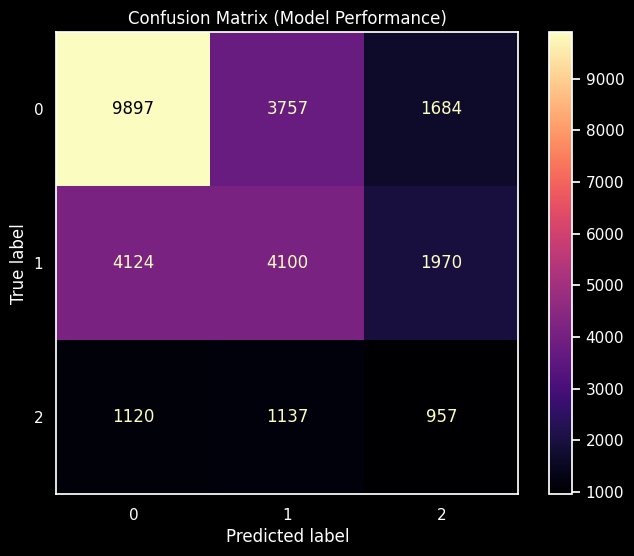

In [74]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = et_model.predict(X_test)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")

print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='magma', ax=ax)
plt.title("Confusion Matrix (Model Performance)")
plt.show()

/tmp/ipykernel_4707/655892325.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


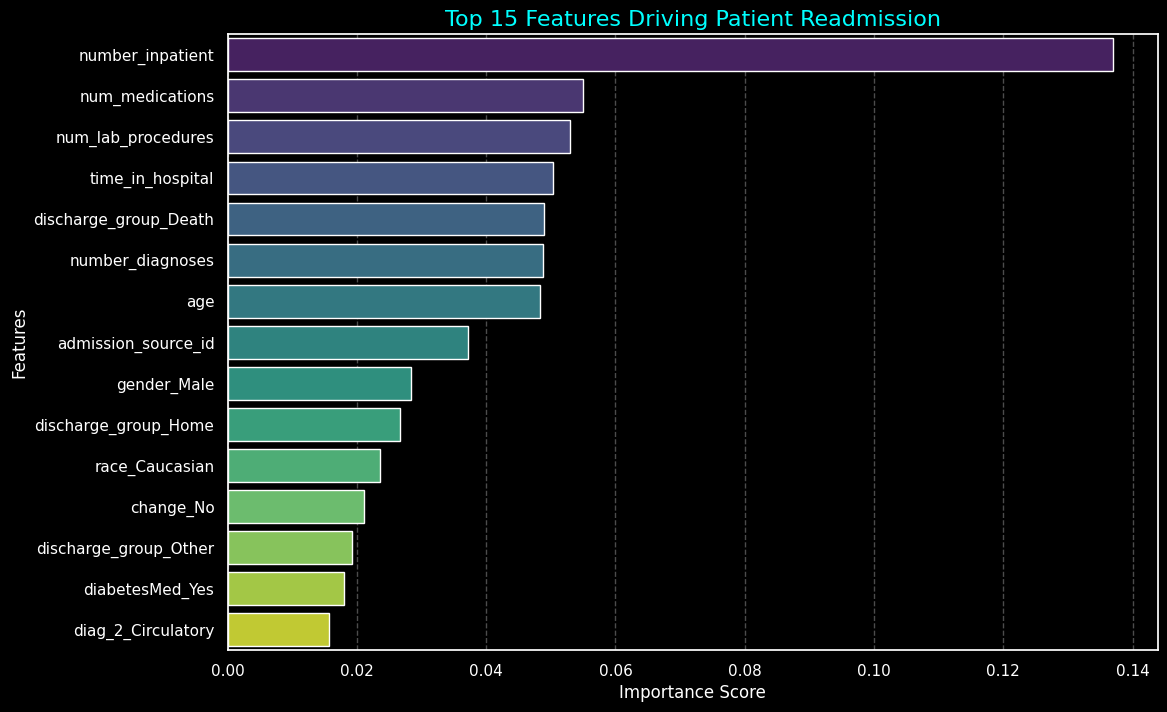

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = et_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.style.use('dark_background')
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis'
    )

plt.title('Top 15 Features Driving Patient Readmission', fontsize=16, color='cyan')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

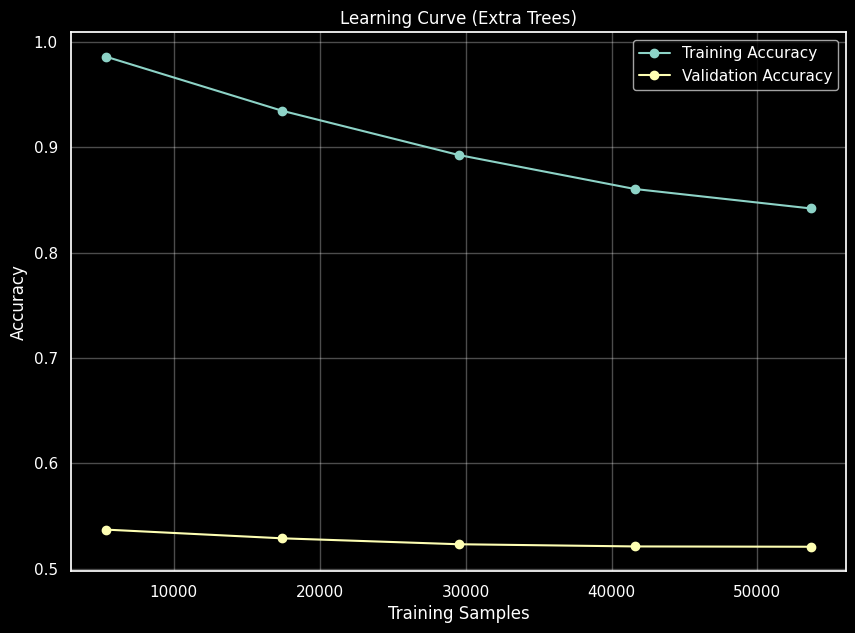

In [76]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=et_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, label="Training Accuracy", marker='o')
plt.plot(train_sizes, test_mean, label="Validation Accuracy", marker='o')
plt.title("Learning Curve (Extra Trees)")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

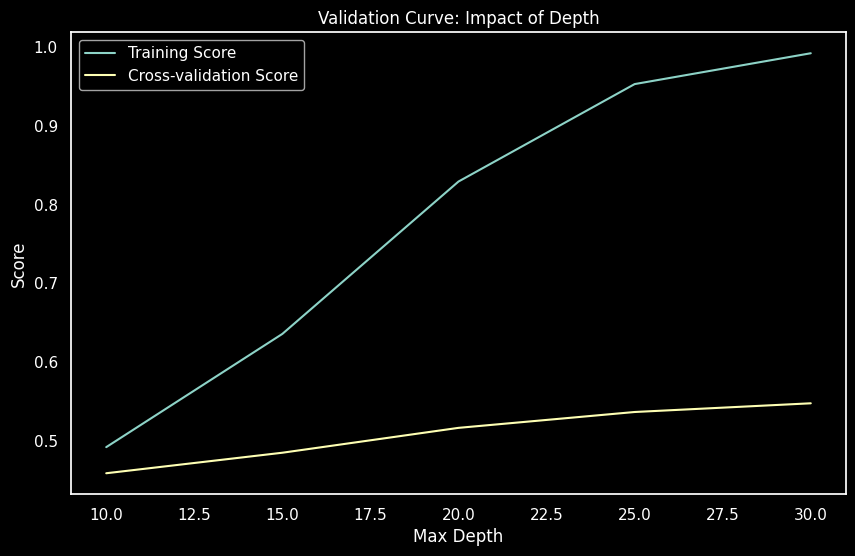

In [77]:
from sklearn.model_selection import validation_curve

param_range = [10, 15, 20, 25, 30]
train_scores, test_scores = validation_curve(
    ExtraTreesClassifier(class_weight='balanced', random_state=42),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5, scoring="accuracy"
)

plt.figure(figsize=(10, 6))
plt.plot(param_range, np.mean(train_scores, axis=1), label="Training Score")
plt.plot(param_range, np.mean(test_scores, axis=1), label="Cross-validation Score")
plt.title("Validation Curve: Impact of Depth")
plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.legend()
plt.show()

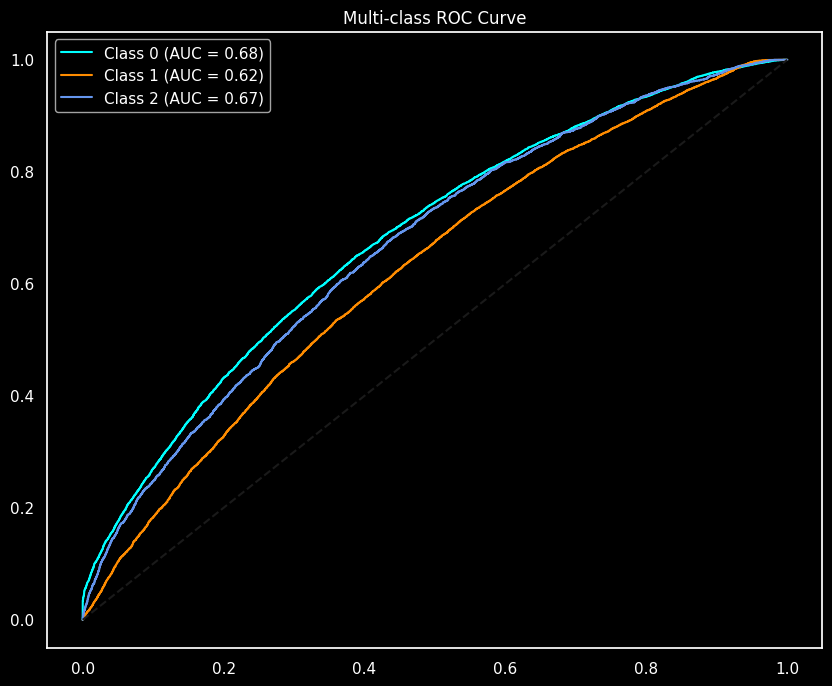

In [78]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = et_model.predict_proba(X_test)

plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multi-class ROC Curve")
plt.legend()
plt.show()

In [79]:
from sklearn.feature_selection import RFE
rfe_selector = RFE(et_model, n_features_to_select=10)
rfe_selector.fit(X_train, y_train)
selected_features = X_train.columns[rfe_selector.support_]
print("Best 10 Features:", selected_features.tolist())

Best 10 Features: ['age', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_inpatient', 'number_diagnoses', 'gender_Male', 'diag_2_Endocrine_Diabetes', 'diag_3_Endocrine_Diabetes']


--- Final Model Performance ---
              precision    recall  f1-score   support

           0       0.62      0.73      0.67     15338
           1       0.44      0.18      0.25     10194
           2       0.18      0.38      0.24      3214

    accuracy                           0.49     28746
   macro avg       0.41      0.43      0.39     28746
weighted avg       0.51      0.49      0.47     28746



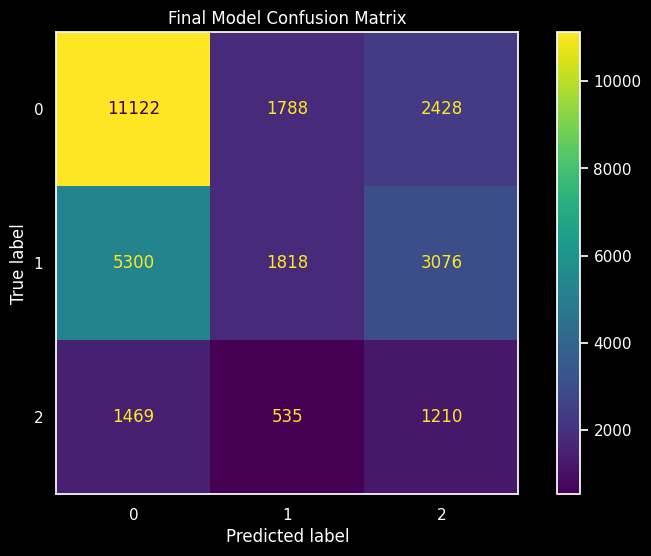

In [82]:
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

final_et_model = ExtraTreesClassifier(
    n_estimators=1000,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_et_model.fit(X_train_final, y_train)

y_pred_final = final_et_model.predict(X_test_final)
print("--- Final Model Performance ---")
print(classification_report(y_test, y_pred_final))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap='viridis')
plt.title("Final Model Confusion Matrix")
plt.show()

In [83]:
train_acc = final_et_model.score(X_train_final, y_train)
print(f"Training Accuracy: {train_acc:.2%}")

Training Accuracy: 52.76%


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


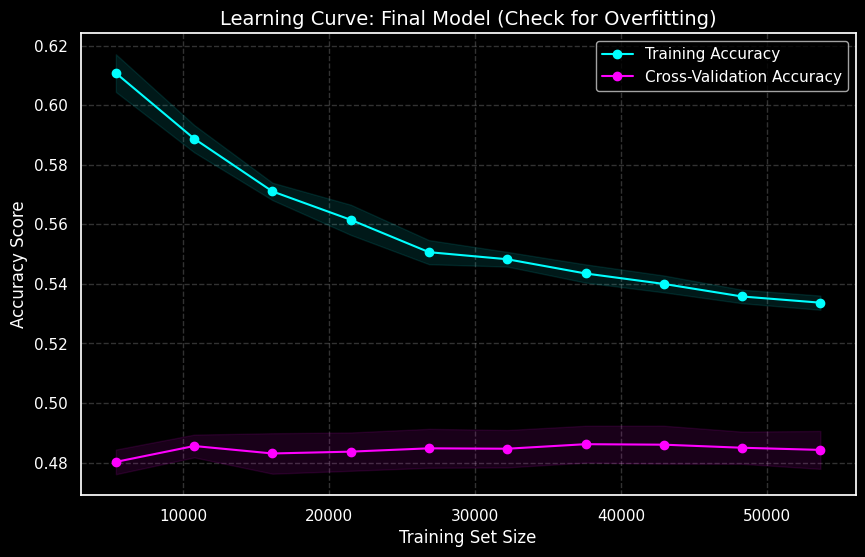

Final Training Accuracy: 53.37%
Final Validation Accuracy: 48.42%
Accuracy Gap: 4.95%


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=final_et_model,
    X=X_train_final,
    y=y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, 'o-', color="cyan", label="Training Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="cyan")

plt.plot(train_sizes, test_mean, 'o-', color="magenta", label="Cross-Validation Accuracy")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="magenta")

plt.title("Learning Curve: Final Model (Check for Overfitting)", fontsize=14, color='white')
plt.xlabel("Training Set Size", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(loc="best")
plt.grid(axis='both', linestyle='--', alpha=0.2)
plt.show()

print(f"Final Training Accuracy: {train_mean[-1]:.2%}")
print(f"Final Validation Accuracy: {test_mean[-1]:.2%}")
print(f"Accuracy Gap: {(train_mean[-1] - test_mean[-1]):.2%}")